# 03 — PageRank parameter analysis

## Goal

Đánh giá damping, tolerance và giới hạn vòng lặp sau khi chọn threshold trên train.

## Setup

Khởi tạo đường dẫn, module thuật toán và thư mục artifact.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / 'data' / 'DUC_TEXT').is_dir():
            PROJECT_ROOT = candidate
            break

NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'textrank-parameter-analysis'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from experiment_utils import *

TRAIN_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'train'
TEST_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'test'
REFERENCE_DIR = PROJECT_ROOT / 'data' / 'DUC_SUM'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'output' / 'textrank-parameter-analysis'
CSV_DIR = OUTPUT_DIR / 'csv'
CHART_DIR = OUTPUT_DIR / 'charts'
CSV_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Project: {PROJECT_ROOT}')
print(f'Output : {OUTPUT_DIR}')

Project: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice
Output : /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/textrank-parameter-analysis


## Steps

### 1. Load the selected threshold

In [2]:
threshold_rows = read_csv(CSV_DIR / '02-threshold-summary.csv')
best_threshold_row = rank_configurations(threshold_rows, required_topics=50)[0]
BEST_THRESHOLD = float(best_threshold_row['similarity_threshold'])
print('Using train-selected threshold:', BEST_THRESHOLD)

Using train-selected threshold: 0.02


### 2. Sweep PageRank parameters

In [3]:
DAMPINGS = [0.70, 0.80, 0.85, 0.90, 0.95]
TOLERANCES = [1e-4, 1e-6, 1e-8]
MAX_ITERATIONS = [100, 300, 1000]
configs = [TextRankConfig(similarity_threshold=BEST_THRESHOLD,
                          pagerank_damping=damping,
                          pagerank_tolerance=tolerance,
                          pagerank_max_iterations=max_iterations)
           for damping in DAMPINGS for tolerance in TOLERANCES for max_iterations in MAX_ITERATIONS]
pagerank_details, pagerank_summaries = run_sweep(TRAIN_DIR, REFERENCE_DIR, configs, 'train')
ranked_pagerank = rank_configurations(pagerank_summaries, required_topics=50)
write_csv(CSV_DIR / '03-pagerank-topic-metrics.csv', pagerank_details, DETAIL_FIELDS)
write_csv(CSV_DIR / '03-pagerank-summary.csv', ranked_pagerank, SUMMARY_FIELDS)
best_pagerank_row = ranked_pagerank[0]
print('Best PageRank config:', best_pagerank_row['config_id'])

Best PageRank config: t=0.02|d=0.85|tol=1e-08|iter=1000|words=100|mmr=0.70


### 3. Plot quality and convergence

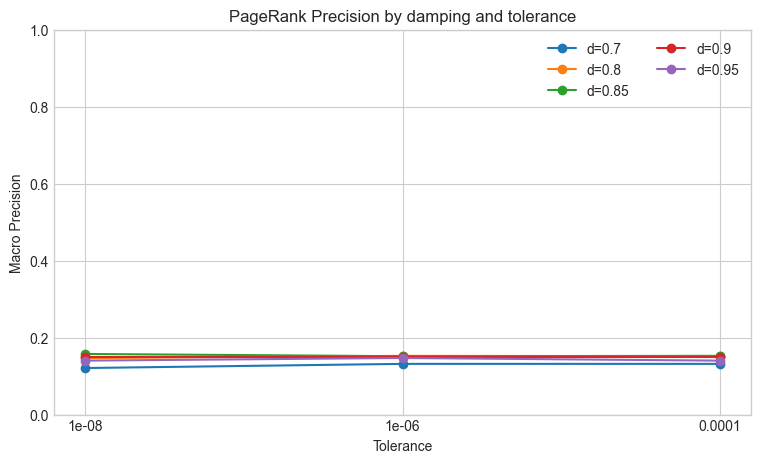

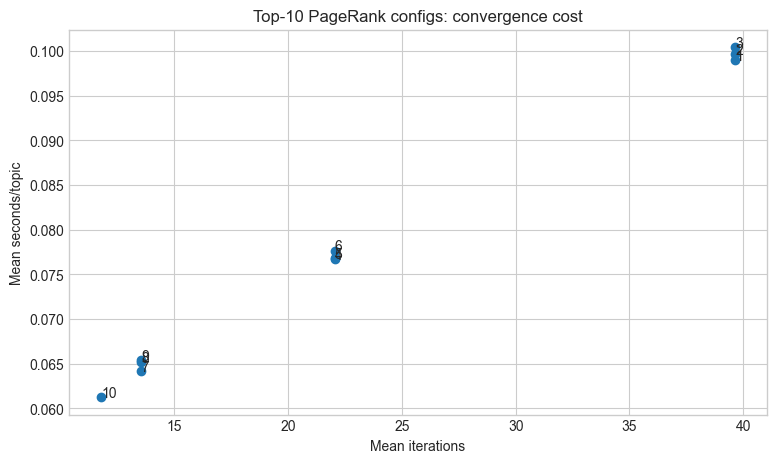

In [4]:
converged = [row for row in pagerank_summaries if row['converged_topics'] == 50]
fig, ax = plt.subplots(figsize=(9, 5))
for damping in DAMPINGS:
    rows = sorted([row for row in converged
                   if row['pagerank_damping'] == damping and row['pagerank_max_iterations'] == 1000],
                  key=lambda row: row['pagerank_tolerance'])
    ax.plot([str(row['pagerank_tolerance']) for row in rows],
            [row['macro_precision'] for row in rows], marker='o', label=f'd={damping}')
ax.set(title='PageRank Precision by damping and tolerance', xlabel='Tolerance', ylabel='Macro Precision', ylim=(0, 1))
ax.legend(ncol=2)
fig.savefig(CHART_DIR / '03-pagerank-quality.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
labels = [row['config_id'] for row in ranked_pagerank[:10]]
ax.scatter([row['mean_pagerank_iterations'] for row in ranked_pagerank[:10]],
           [row['mean_runtime_seconds'] for row in ranked_pagerank[:10]])
for label, row in zip(labels, ranked_pagerank[:10]):
    ax.annotate(str(row['rank']), (row['mean_pagerank_iterations'], row['mean_runtime_seconds']))
ax.set(title='Top-10 PageRank configs: convergence cost', xlabel='Mean iterations', ylabel='Mean seconds/topic')
fig.savefig(CHART_DIR / '03-pagerank-convergence.png', dpi=160, bbox_inches='tight')
plt.show()

## Checks

Các assertion dưới đây bảo đảm artifact và dữ liệu của notebook đầy đủ.

In [5]:
assert len(pagerank_summaries) == 45
assert ranked_pagerank
for path in [CSV_DIR / '03-pagerank-summary.csv', CSV_DIR / '03-pagerank-topic-metrics.csv',
             CHART_DIR / '03-pagerank-quality.png', CHART_DIR / '03-pagerank-convergence.png']:
    assert path.is_file() and path.stat().st_size > 0, path
print(f'Converged configs: {len(ranked_pagerank)}/45')

Converged configs: 42/45


## Takeaways

In [6]:
print(f"Best converged PageRank setting: damping={best_pagerank_row['pagerank_damping']}, "
      f"tolerance={best_pagerank_row['pagerank_tolerance']}, "
      f"max_iterations={best_pagerank_row['pagerank_max_iterations']}.")
print(f"Precision={float(best_pagerank_row['macro_precision']):.4f}; "
      f"mean iterations={float(best_pagerank_row['mean_pagerank_iterations']):.1f}.")

Best converged PageRank setting: damping=0.85, tolerance=1e-08, max_iterations=1000.
Precision=0.1575; mean iterations=39.6.
